# Graph Neural Network (GNN)

## Part I) GIN implementation :

Implement a graph isomorphism network model (GIN), then test your implementation on the PROTEINS dataset.

The task is to predict if a protein is an enzyme or not. It's a graph level binary classification task.

To install torch_geometric : pip install torch_geometric

More info on : https://pytorch-geometric.readthedocs.io/en/latest/install/installation.html

In [31]:
#main import function and library
import torch_geometric as tg
import numpy as np
import torch
from torch_geometric.datasets import TUDataset
from torch_geometric.loader import DataLoader
from torch.nn import Linear, Parameter, Sequential, ReLU, BatchNorm1d
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import add_self_loops, degree
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINConv, global_add_pool

In [32]:
dataset = tg.datasets.TUDataset(root='/tmp/PROTEINS', name='PROTEINS', use_node_attr=True)
dataset = dataset.shuffle()
train_dataset = dataset[:800]
val_dataset = dataset[800:956]
test_dataset = dataset[956:]


print('Number of training graphs: ',len(train_dataset))
print('Number of validation graphs: ',len(test_dataset))
print('Number of test graphs: ',len(test_dataset))

Number of training graphs:  800
Number of validation graphs:  157
Number of test graphs:  157


In [33]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device utilisé: {device}")

Device utilisé: cuda


In [34]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [35]:
print(f"Nombre de features par noeud (Input du modèle) : {dataset.num_features}")
print(f"Nombre de classes (Output du modèle) : {dataset.num_classes}")

Nombre de features par noeud (Input du modèle) : 4
Nombre de classes (Output du modèle) : 2


In [36]:
#GIN model with pytorch geometric
import torch
import torch.nn.functional as F
from torch.nn import Sequential, Linear, BatchNorm1d, ReLU
from torch_geometric.nn import GINConv, global_add_pool

class GIN(torch.nn.Module):
    def __init__(self, dim_h=32):
        super(GIN, self).__init__()
        
        num_features = dataset.num_node_features
        num_classes = dataset.num_classes

        mlp1 = Sequential(
            Linear(num_features, dim_h), 
            BatchNorm1d(dim_h), 
            ReLU(),
            Linear(dim_h, dim_h), 
            ReLU()
        )
        self.conv1 = GINConv(mlp1)

        mlp2 = Sequential(
            Linear(dim_h, dim_h), 
            BatchNorm1d(dim_h), 
            ReLU(),
            Linear(dim_h, dim_h), 
            ReLU()
        )
        self.conv2 = GINConv(mlp2)
    
        mlp3 = Sequential(
            Linear(dim_h, dim_h), 
            BatchNorm1d(dim_h), 
            ReLU(),
            Linear(dim_h, dim_h), 
            ReLU()
        )
        self.conv3 = GINConv(mlp3)

        self.lin = Linear(dim_h, num_classes)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        # 1. Message Passing
        x = self.conv1(x, edge_index)
        x = self.conv2(x, edge_index)
        x = self.conv3(x, edge_index)

        # 2. Aggregation Globale (Readout)
        # On somme les vecteurs de tous les noeuds du graphe
        x = global_add_pool(x, batch)

        # 3. Classification
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)
        
        return F.log_softmax(x, dim=1)

In [37]:
#Optionnal
#Specified layer
class MyLayer(MessagePassing):
    def __init__(self, in_channels, out_channels):
        super(MyLayer, self).__init__(aggr='add')  # "Add" aggregation.
        self.lin = Linear(in_channels, out_channels)
        self.bias = Parameter(torch.Tensor(out_channels))
        self.reset_parameters()

    def reset_parameters(self):
        torch.nn.init.zeros_(self.bias)
        self.lin.reset_parameters()
        

    def forward(self, x, edge_index):
        edge_index, _ = add_self_loops(edge_index, num_nodes=x.size(0))

        x = self.lin(x)

        return self.propagate(edge_index, x=x) + self.bias

In [44]:
# Training function
model = GIN(dim_h=32).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = torch.nn.NLLLoss() # Adapté pour la classification avec log_softmax

def train(model, loader):
    model.train()
    total_loss = 0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        
        out = model(data)
        
        # data.y est de taille [Batch], c'est ce qu'attend NLLLoss pour la classification
        loss = criterion(out, data.y)
        
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return total_loss / len(loader.dataset)

In [30]:
# To eval the model performances
def eval_model(model,loader):
    model.eval()
    correct = 0
    for data in loader:
        data = data.to(device)
        
        # Pas de calcul de gradients ici (plus rapide)
        with torch.no_grad():
            out = model(data)
            
        # On prend la classe avec la plus haute probabilité (argmax)
        pred = out.argmax(dim=1)
        
        # On compare avec la vraie étiquette (y)
        correct += int((pred == data.y).sum())
    return correct / len(loader.dataset)

Début de l'entraînement...
Epoch 010: Loss=0.6332, Train Acc=0.7000, Test Acc=0.6752
Epoch 020: Loss=0.5769, Train Acc=0.7250, Test Acc=0.7261
Epoch 030: Loss=0.6021, Train Acc=0.6737, Test Acc=0.6497
Epoch 040: Loss=0.5915, Train Acc=0.7438, Test Acc=0.7261
Epoch 050: Loss=0.5902, Train Acc=0.7338, Test Acc=0.7452
Epoch 060: Loss=0.5881, Train Acc=0.7075, Test Acc=0.6943
Epoch 070: Loss=0.5786, Train Acc=0.7388, Test Acc=0.6752
Epoch 080: Loss=0.6073, Train Acc=0.7175, Test Acc=0.6688
Epoch 090: Loss=0.5730, Train Acc=0.7662, Test Acc=0.7261
Epoch 100: Loss=0.5948, Train Acc=0.7388, Test Acc=0.6943


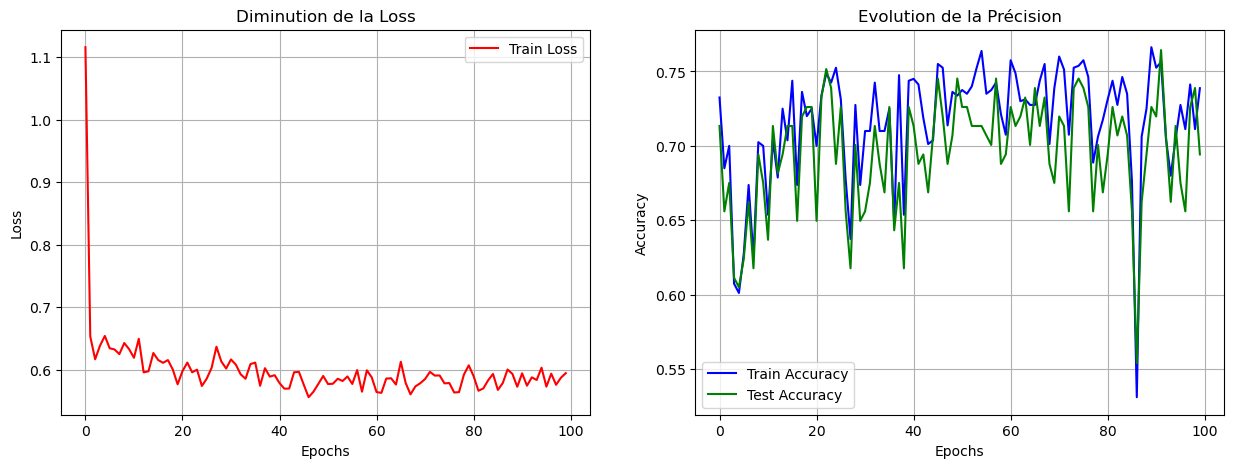

In [45]:
import matplotlib.pyplot as plt

train_losses = []
train_accs = []
test_accs = []

print("Début de l'entraînement...")

for epoch in range(1, 101): # 100 epochs
    # Entraînement et calcul des métriques
    loss = train(model, train_loader)
    train_acc = eval_model(model, train_loader)
    test_acc = eval_model(model, test_loader)
    
    # Stockage
    train_losses.append(loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)
    
    if epoch % 10 == 0:
        print(f'Epoch {epoch:03d}: Loss={loss:.4f}, Train Acc={train_acc:.4f}, Test Acc={test_acc:.4f}')

# --- FONCTION DE TRACÉ DES COURBES ---
def plot_learning_curves(losses, train_acc, test_acc):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Courbe de Loss
    ax1.plot(losses, label='Train Loss', color='red')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.set_title('Diminution de la Loss')
    ax1.legend()
    ax1.grid(True)
    
    # Courbes d'Accuracy
    ax2.plot(train_acc, label='Train Accuracy', color='blue')
    ax2.plot(test_acc, label='Test Accuracy', color='green')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.set_title('Evolution de la Précision')
    ax2.legend()
    ax2.grid(True)
    
    plt.show()

# Afficher les courbes
plot_learning_curves(train_losses, train_accs, test_accs)

Explain what does the Aggregation and Update functions of GIN? Why it's called a message-passing architecture?

## Part II) Graph learning challenge

Now you have to implement and train a GNN on the ZFR database, you can certainly test your GIN from part I) but also any GNN you want (GCN, GAT...).

The goal is to predict three properties per graph, it's a graph regression task.

First, predict each property separately, then all three properties together.

This part of the practical work will be assessed on the basis of your experimental protocol and the results obtained.

Once your GNN is ready, download the test database and make predictions using your GNN.

You should submit your GNN predictions in a .csv file to Universitice. Your predictions should be in the same order as the test dataset. Your predictions should respect the following csv format:

- separator ";"
- column names : "prop1","prop2", "prop3", "allprop".
- for "allprop" your predictions should be a list of three values per graphs.
- csv file name :  yourName_GNNmodelName.csv

Any csv files that do not respect the above format will not be processed.

An accessible sheet will be filled with your name and your results (MAE and model name only) and a baseline (GCN model). You can submit any attempts of predictions, just modify your file on Universitice. The results will be processed every week before the practical session.

https://docs.google.com/spreadsheets/d/1fTZyV3DSa39vVlEYxN747YIGSR7ONoYEQc4Z3CHW3uM/edit?gid=0#gid=0

For the final rending of this work, you must submit to Universitice: this notebook, the code that gave you the best MAE entry (in .py or .ipynb file), but also a doc with all your reasoning, methodology and different experiments you had done and why.

For example: the list of hyperparameters and a short description of the model used to obtain your best result, the hyperparameterisation protocol, the different sizes of architectures, the number of trials you performed, the learning protocol, the tested loss, the tested layers, the learning rate, the scheduler, the drop-out, etc...

The goal of this challenge is not just to code a GNN, but to understand how to train a deep neural network well on graph data.

The final grade for this work will focus mainly on your results, your originality and the protocol you used. Good luck!

In [45]:
# After dowloading the databases import ZFR to load datasets 
from ZFRdataset import ZFR
dataset_train = ZFR('dataset/ZFR',dataset = 'train')
dataset_test = ZFR('dataset/ZFR',dataset = 'test')

In [ ]:
#Important for reproducibility of your results
def set_seed(seed = 42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

In [3]:
print(dataset_test.data)

Data(x=[188602, 13], edge_index=[2, 382970], edge_attr=[382970, 4], pos=[188602, 3], z=[188602])


In [4]:
print(dataset_train.data)

Data(x=[860270, 13], edge_index=[2, 1789766], edge_attr=[1789766, 4], y=[48479, 3], pos=[860270, 3], z=[860270])
